# Housing Price Prediction Project

## 1. Data Loading
This section loads the Kaggle housing dataset and provides an initial overview of the data structure.

In [1]:
# Imports
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"

# Create output folder if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_DIR / "train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 2. Data Cleaning
This section handles missing values to improve data quality and prepare the dataset for modeling.

In [3]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [4]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print('categorical:', len(categorical_cols))
print('numerical:', len(numerical_cols))

print(categorical_cols)
print(numerical_cols)

categorical: 43
numerical: 38
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
     

In [5]:
# Fill missing values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
df[categorical_cols] = df[categorical_cols].fillna('None')

# Confirm no missing values remain
df.isnull().sum().sum()

np.int64(0)

## 3. Feature Engineering
This section transforms categorical variables using one-hot encoding so they can be used in machine learning models.

In [6]:
df_encoded = pd.get_dummies(df)

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 305 entries, Id to SaleCondition_Partial
dtypes: bool(267), float64(3), int64(35)
memory usage: 814.2 KB


## 4. Train-Test Split
This section splits the dataset into training and testing sets for model evaluation.

In [7]:
X = df_encoded.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Baseline Model (Linear Regression)
This section builds a baseline linear regression model for comparison.

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_r2 = lr_model.score(X_test, y_test)
print("R2 of LinearRegression:", lr_r2)

R2 of LinearRegression: 0.44347331106439203


## 6. Model Improvement (Random Forest, no log)
This section applies a Random Forest model to capture non-linear relationships and improve predictive performance.

In [9]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_r2 = rf_model.score(X_test, y_test)
print("R2 of RandomForestRegressor:", rf_r2)

R2 of RandomForestRegressor: 0.8874611711186082


## 7. Model Evaluation
This section evaluates model performance and visualizes prediction errors. The Random Forest model performs well overall, but it tends to underestimate high-priced houses.

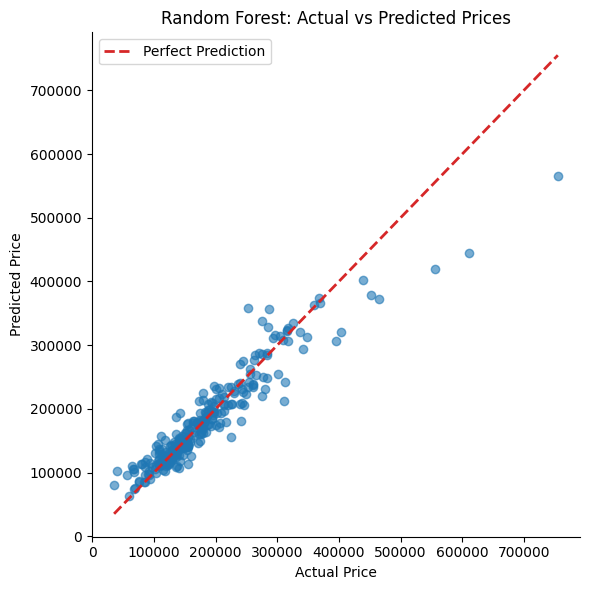

In [10]:
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='tab:blue')

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='tab:red', 
    linestyle='--', 
    linewidth=2, 
    label='Perfect Prediction'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=300)
plt.show()

From the scatter plot, predictions are relatively accurate for lower-priced houses, while higher-priced houses tend to be underestimated. This suggests that the model struggles more with rare high-value properties.

## 8. Model Improvement (Random Forest with Log Transformation)
This section applies log transformation to the target variable to reduce skewness and test whether model stability can be improved.

In [11]:
y_log = np.log1p(df['SalePrice'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

rf_model_log = RandomForestRegressor(random_state=42)
rf_model_log.fit(X_train_log, y_train_log)

RandomForestRegressor(random_state=42)

## 9. Model Evaluation (After Log)
This section evaluates the Random Forest model after log transformation.

In [12]:
y_pred_log = rf_model_log.predict(X_test_log)

# Convert back to original price scale
y_pred_rf_log = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

rf_log_r2 = r2_score(y_test_actual, y_pred_rf_log)
print("R2 of RandomForestRegressor after log transformation:", rf_log_r2)

R2 of RandomForestRegressor after log transformation: 0.88442272839372


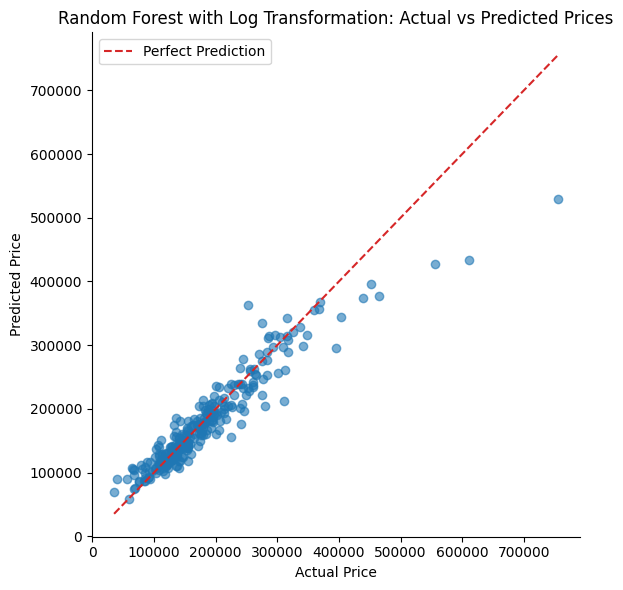

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_actual, y_pred_rf_log, alpha=0.6, color='tab:blue')

min_val = min(y_test_actual.min(), y_pred_rf_log.min())
max_val = max(y_test_actual.max(), y_pred_rf_log.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val],
    color='tab:red', 
    linestyle='--', 
    label='Perfect Prediction'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest with Log Transformation: Actual vs Predicted Prices")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted_log.png", dpi=300)
plt.show()

Although log transformation was expected to reduce skewness, it did not significantly improve prediction accuracy for high-priced houses. The underestimation pattern remains visible in the upper price range.

## 10. Cross Validation (Model Comparison)
This section compares model stability before and after log transformation using cross-validation.

In [14]:
# Cross-validation without log
scores_no_log = cross_val_score(
    RandomForestRegressor(random_state=42),
    X,
    y,
    cv=5,
    scoring="r2"
)

# Cross-validation with log
scores_log = cross_val_score(
    RandomForestRegressor(random_state=42),
    X,
    y_log,
    cv=5,
    scoring="r2"
)

print("CV R2 (no log):", scores_no_log.mean())
print("CV R2 (log):", scores_log.mean())

CV R2 (no log): 0.8574145860205105
CV R2 (log): 0.8709127579418828


The log transformation does not improve the single test-set R2, but it improves the cross-validation mean score. This suggests that log transformation enhances model stability and generalization across different splits, even if the test result remains similar.

## 11. Feature Importance
This section identifies the most important features influencing housing prices using the final Random Forest model.

In [15]:
importance = rf_model_log.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
top_features = feat_imp.sort_values(ascending=False).head(10).sort_values()

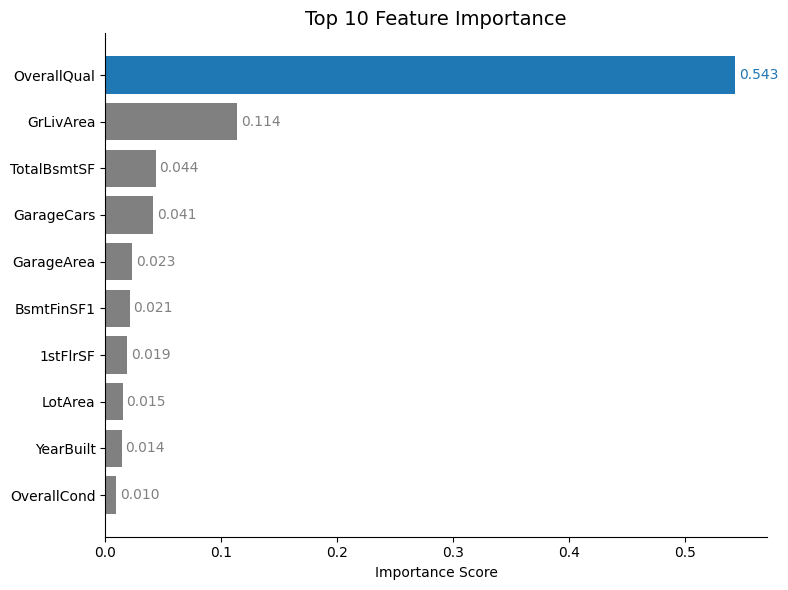

In [16]:
plt.figure(figsize=(8, 6))

colors = ['gray'] * len(top_features)
colors[-1] = 'tab:blue'

bars = plt.barh(top_features.index, top_features.values, color=colors)

for bar in bars:
    width = bar.get_width()
    color = bar.get_facecolor()
    plt.text(width + 0.003,
             bar.get_y() + bar.get_height()/2,
             f"{width:.3f}",
             va='center',
             color=color
    )

plt.title('Top 10 Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_10_feature_importance.png", dpi=300)
plt.show()

The most important features include overall quality, living area, basement area, and garage size, which align with real-world housing valuation factors.

## 12. Conclusion

- Linear Regression provides a useful baseline but underperforms on this dataset.
- Random Forest significantly improves predictive performance.
- The model tends to underestimate high-priced houses.
- Log transformation does not significantly improve the test-set R2, but it improves cross-validation performance, suggesting better model stability.
- Important drivers of housing prices include overall quality, living area, basement area, and garage size.

Overall, this project demonstrates a complete machine learning workflow using real-world housing data, including cleaning, feature engineering, model comparison, evaluation, and interpretation.